### Plotting graphs - before and after coarsening process

In [4]:
import os
import matplotlib.pyplot as plt

from QuantumLogistics import DeltaCoarseningEngine, Route
from QuantumLogistics.LogisticsRoute.VrpRepGraph import vrpRepGraph

dataDir = os.path.join(os.getcwd(), "../../dataset")

TRACKS_NUM = 2

cmtNum:01, coarseningRate:1.0, number of nodes:51
Final coarse graph has 45 nodes
cmtNum:01, coarseningRate:0.9, number of nodes:45
Final coarse graph has 35 nodes
cmtNum:01, coarseningRate:0.7, number of nodes:35
Final coarse graph has 25 nodes
cmtNum:01, coarseningRate:0.5, number of nodes:25
Final coarse graph has 15 nodes
cmtNum:01, coarseningRate:0.3, number of nodes:15
cmtNum:02, coarseningRate:1.0, number of nodes:76
Final coarse graph has 68 nodes
cmtNum:02, coarseningRate:0.9, number of nodes:68
Final coarse graph has 53 nodes
cmtNum:02, coarseningRate:0.7, number of nodes:53
Final coarse graph has 38 nodes
cmtNum:02, coarseningRate:0.5, number of nodes:38
Final coarse graph has 22 nodes
cmtNum:02, coarseningRate:0.3, number of nodes:22
cmtNum:03, coarseningRate:1.0, number of nodes:101
Final coarse graph has 90 nodes
cmtNum:03, coarseningRate:0.9, number of nodes:90
Final coarse graph has 70 nodes
cmtNum:03, coarseningRate:0.7, number of nodes:70
Final coarse graph has 50 nod

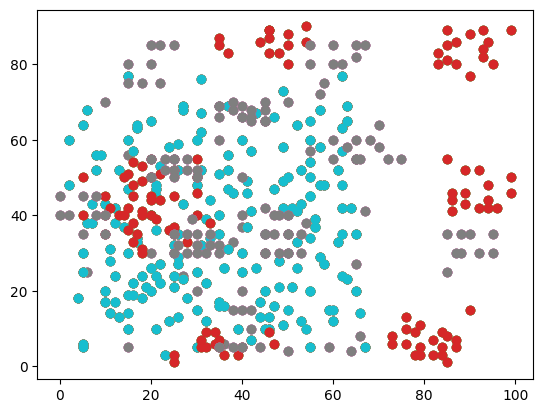

In [14]:
for cmtNum in ['01', '02', '03', '04', '05', '11', '12']:
    for coarseningRate in [1.0, 0.9, 0.7, 0.5, 0.3]:
        cmtFile = "CMT" + cmtNum + ".xml"

        LogisticsNetwork = vrpRepGraph(os.path.join(dataDir, cmtFile))
        LogisticsNetwork.generate_graph()

        coarsenConfig = {"coarsenRate": coarseningRate, "radiusCoefficient": 0.2}
        coarseningEngine = DeltaCoarseningEngine(**coarsenConfig)

        routeConfig = {
            "vehicles": TRACKS_NUM,
            "depot": LogisticsNetwork.nodelist.vehicle["arrival_node"],
            "truckCapacity": max(LogisticsNetwork.nodeCapacities),
        }

        route = Route(
            LogisticsNetwork, coarseningEngine=coarseningEngine, **routeConfig
        )

        route.coarsen = (coarseningRate < 1)

        if route.coarsen:
            route.coarsenGraph()
            plt.scatter(route.originalGraph.coords[:,0], route.originalGraph.coords[:,1])

        print(f"cmtNum:{cmtNum}, coarseningRate:{coarseningRate}, number of nodes:{route.graph.N}")

        plt.scatter(route.graph.coords[:,0], route.graph.coords[:,1])
        plt.savefig(os.path.join(dataDir, "img", f"CMT{cmtNum}.coarseningRate{coarseningRate}.pdf"))
        plt.savefig(os.path.join(dataDir, "img", f"CMT{cmtNum}.coarseningRate{coarseningRate}.png"))
        plt.clf()